# EDA 

- All datasets follow chronological order.
- Each stage holdout comes from the end of that stage.
- Training and holdout are separated by a complete 24-hour NF-only gap.
- Consecutive stages are separated by a complete 24-hour NF-only gap.
- Holdouts remain natural, unaugmented and unused during training.
- Holdouts are close to 15% in each stages.
- Each holdout contain enough FL and NF samples for meaningful evaluation.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

# Find the repository root.
ROOT = Path.cwd()

while not (ROOT / "data_labeling").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("Repository root could not be found.")
    ROOT = ROOT.parent

LABEL_ROOT = ROOT / "data_labeling" / "data_labels"

OLD_LABELS = (
    LABEL_ROOT
    / "simplified_data_labels"
    / "labels_2010_2018_binary.csv"
)

NEW_LABELS = (
    LABEL_ROOT
    / "simplified_data_labels"
    / "labels_2019_2026_july_binary.csv"
)

REPAIR_LABELS = (
    LABEL_ROOT
    / "boundary_supplements"
    / "labels_boundary_repair_binary.csv"
)

OLD_CATALOGUE = (
    ROOT
    / "data_labeling"
    / "Catalogue"
    / "goes_flares_catalogue_2010_2018.csv"
)

NEW_CATALOGUE = (
    ROOT
    / "data_labeling"
    / "Catalogue"
    / "goes_flares_catalogue_2019_2026.csv"
)

for path in [
    OLD_LABELS,
    NEW_LABELS,
    REPAIR_LABELS,
    OLD_CATALOGUE,
    NEW_CATALOGUE,
]:
    assert path.exists(), f"File not found: {path}"

print("Repository:", ROOT)
print("All required files were found.")

Repository: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-
All required files were found.


In [2]:
# Load all binary labels
label_sources = {
    "2010–2018 labels": OLD_LABELS,
    "2019–2026 labels": NEW_LABELS,
    "December 31 repair": REPAIR_LABELS,
}

frames = []

for source_name, path in label_sources.items():
    frame = pd.read_csv(path)

    assert {"label", "goes_class"}.issubset(frame.columns)

    frame = frame[["label", "goes_class"]].copy()
    frame["source"] = source_name

    frames.append(frame)

raw_data = pd.concat(frames, ignore_index=True)

print("Rows before cleaning:", f"{len(raw_data):,}")
display(raw_data.head())

Rows before cleaning: 128,117


,label,goes_class,source
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,0,2010–2018 labels
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,0,2010–2018 labels
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,0,2010–2018 labels
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,0,2010–2018 labels
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,0,2010–2018 labels


In [ ]:
# Parse timestamps and check duplicates


Invalid timestamps: 0
Invalid class values: 0
Duplicated paths: 0
Paths with conflicting labels: 0

Rows after cleaning: 128,117
First observation: 2010-12-06 07:00:00
Last observation: 2026-07-31 23:00:00


In [3]:
timestamp_text = raw_data["label"].str.extract(
    r"HMI\.m(\d{4}\.\d{2}\.\d{2}_\d{2}\.\d{2}\.\d{2})"
)[0]

raw_data["timestamp"] = pd.to_datetime(
    timestamp_text,
    format="%Y.%m.%d_%H.%M.%S",
    errors="coerce",
)

raw_data["goes_class"] = pd.to_numeric(
    raw_data["goes_class"],
    errors="coerce",
)

In [4]:
raw_data

,label,goes_class,source,timestamp
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,0,2010–2018 labels,2010-12-06 07:00:00
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,0,2010–2018 labels,2010-12-06 08:00:00
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,0,2010–2018 labels,2010-12-06 09:00:00
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,0,2010–2018 labels,2010-12-06 10:00:00
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,0,2010–2018 labels,2010-12-06 11:00:00
...,...,...,...,...
128112,2018/12/31/HMI.m2018.12.31_19.00.00.jpg,0,December 31 repair,2018-12-31 19:00:00
128113,2018/12/31/HMI.m2018.12.31_20.00.00.jpg,0,December 31 repair,2018-12-31 20:00:00
128114,2018/12/31/HMI.m2018.12.31_21.00.00.jpg,0,December 31 repair,2018-12-31 21:00:00
128115,2018/12/31/HMI.m2018.12.31_22.00.00.jpg,0,December 31 repair,2018-12-31 22:00:00


In [7]:
data = (
    raw_data
    .sort_values(["timestamp", "source"])
    .drop_duplicates("label", keep="last")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

In [8]:
data

,label,goes_class,source,timestamp
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,0,2010–2018 labels,2010-12-06 07:00:00
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,0,2010–2018 labels,2010-12-06 08:00:00
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,0,2010–2018 labels,2010-12-06 09:00:00
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,0,2010–2018 labels,2010-12-06 10:00:00
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,0,2010–2018 labels,2010-12-06 11:00:00
...,...,...,...,...
128112,2026/07/31/HMI.m2026.07.31_19.00.00.jpg,0,2019–2026 labels,2026-07-31 19:00:00
128113,2026/07/31/HMI.m2026.07.31_20.00.00.jpg,0,2019–2026 labels,2026-07-31 20:00:00
128114,2026/07/31/HMI.m2026.07.31_21.00.00.jpg,0,2019–2026 labels,2026-07-31 21:00:00
128115,2026/07/31/HMI.m2026.07.31_22.00.00.jpg,0,2019–2026 labels,2026-07-31 22:00:00


In [10]:

print("First observation:", data["timestamp"].min())
print("Last observation:", data["timestamp"].max())

First observation: 2010-12-06 07:00:00
Last observation: 2026-07-31 23:00:00


In [11]:
# Summarize the three label sources
source_summary = (
    raw_data.groupby("source")
    .agg(
        samples=("label", "size"),
        FL=("goes_class", "sum"),
        start=("timestamp", "min"),
        end=("timestamp", "max"),
    )
)

source_summary["NF"] = (
    source_summary["samples"] - source_summary["FL"]
)

source_summary["FL_percent"] = (
    100 * source_summary["FL"] / source_summary["samples"]
)

source_summary = source_summary[
    ["start", "end", "samples", "FL", "NF", "FL_percent"]
]

display(source_summary)

,start,end,samples,FL,NF,FL_percent
source,,,,,,
2010–2018 labels,2010-12-06 07:00:00,2018-12-30 23:00:00,63285,8975,54310,14.181876
2019–2026 labels,2019-01-01 00:00:00,2026-07-31 23:00:00,64808,15954,48854,24.617331
December 31 repair,2018-12-31 00:00:00,2018-12-31 23:00:00,24,0,24,0.000000


In [12]:
boundary_check = data[
    data["timestamp"].between(
        "2018-12-29 00:00:00",
        "2019-01-03 23:00:00",
    )
].copy()

boundary_check["date"] = boundary_check["timestamp"].dt.date
boundary_check["hour"] = boundary_check["timestamp"].dt.hour

# Each cell is:
# 0 = NF
# 1 = FL
# NaN = missing observation
boundary_grid = boundary_check.pivot_table(
    index="date",
    columns="hour",
    values="goes_class",
    aggfunc="first",
)

boundary_grid = boundary_grid.reindex(columns=range(24))

display(boundary_grid)

boundary_daily_summary = (
    boundary_check.groupby("date")
    .agg(
        available_hours=("timestamp", "size"),
        FL=("goes_class", "sum"),
    )
)

boundary_daily_summary["NF"] = (
    boundary_daily_summary["available_hours"]
    - boundary_daily_summary["FL"]
)

boundary_daily_summary["missing_hours"] = (
    24 - boundary_daily_summary["available_hours"]
)

display(boundary_daily_summary)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2018-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-12-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2019-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,available_hours,FL,NF,missing_hours
date,,,,
2018-12-29,24,0,24,0
2018-12-30,24,0,24,0
2018-12-31,24,0,24,0
2019-01-01,24,0,24,0
2019-01-02,19,0,19,5
2019-01-03,24,0,24,0


In [13]:
old_events = pd.read_csv(OLD_CATALOGUE)
new_events = pd.read_csv(NEW_CATALOGUE)

old_events_clean = pd.DataFrame({
    "event_time": pd.to_datetime(
        old_events["start_time"],
        errors="coerce",
    ),
    "flare_class": old_events["goes_class"].astype(str),
    "catalogue": "2010–2018",
})

new_events_clean = pd.DataFrame({
    "event_time": pd.to_datetime(
        new_events["event_start"],
        format="%Y/%m/%d %H:%M:%S",
        errors="coerce",
    ),
    "flare_class": new_events["event_GOES"].astype(str),
    "catalogue": "2019–2026",
})

flare_events = pd.concat(
    [old_events_clean, new_events_clean],
    ignore_index=True,
)

flare_events = (
    flare_events
    .dropna(subset=["event_time"])
    .drop_duplicates(["event_time", "flare_class"])
    .sort_values("event_time")
    .reset_index(drop=True)
)

flare_events["is_MX"] = (
    flare_events["flare_class"]
    .str.upper()
    .str.startswith(("M", "X"))
)

mx_events = flare_events[flare_events["is_MX"]].copy()

print("All catalogue events:", f"{len(flare_events):,}")
print("M/X events:", f"{len(mx_events):,}")

All catalogue events: 38,345
M/X events: 2,509


Yearly data distribution

In [14]:
data["year"] = data["timestamp"].dt.year

yearly_summary = (
    data.groupby("year")["goes_class"]
    .agg(samples="size", FL="sum")
)

yearly_summary["NF"] = (
    yearly_summary["samples"] - yearly_summary["FL"]
)

yearly_summary["FL_percent"] = (
    100 * yearly_summary["FL"] / yearly_summary["samples"]
)

mx_events["year"] = mx_events["event_time"].dt.year

events_by_year = (
    mx_events.groupby("year")
    .size()
    .rename("MX_events")
)

yearly_summary = yearly_summary.join(
    events_by_year,
    how="left",
)

yearly_summary["MX_events"] = (
    yearly_summary["MX_events"]
    .fillna(0)
    .astype(int)
)

display(yearly_summary)

,samples,FL,NF,FL_percent,MX_events
year,,,,,
2010,562,0,562,0.000000,8
2011,6528,1235,5293,18.918505,119
2012,6516,1358,5158,20.841007,136
2013,7656,1436,6220,18.756531,111
2014,8405,2702,5703,32.147531,225
2015,8511,1664,6847,19.551169,132
2016,8337,250,8087,2.998681,16
2017,8377,330,8047,3.939358,43
2018,8417,0,8417,0.000000,0


Monthly FL distribution

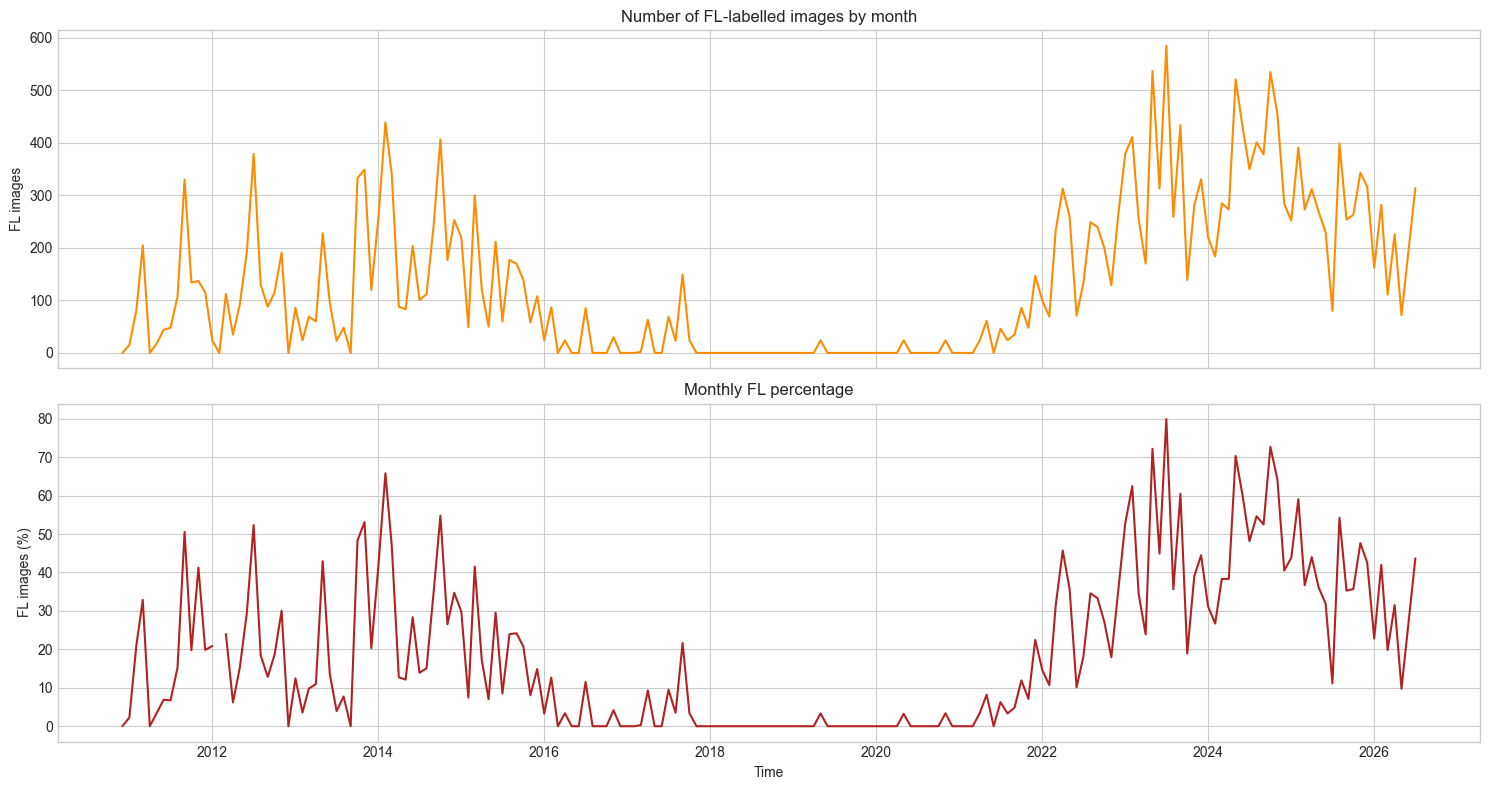

In [15]:
monthly_summary = (
    data.set_index("timestamp")
    .resample("MS")["goes_class"]
    .agg(samples="size", FL="sum")
)

monthly_summary["NF"] = (
    monthly_summary["samples"] - monthly_summary["FL"]
)

monthly_summary["FL_percent"] = np.where(
    monthly_summary["samples"] > 0,
    100 * monthly_summary["FL"] / monthly_summary["samples"],
    np.nan,
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 8),
    sharex=True,
)

axes[0].plot(
    monthly_summary.index,
    monthly_summary["FL"],
    color="darkorange",
)

axes[0].set_title("Number of FL-labelled images by month")
axes[0].set_ylabel("FL images")

axes[1].plot(
    monthly_summary.index,
    monthly_summary["FL_percent"],
    color="firebrick",
)

axes[1].set_title("Monthly FL percentage")
axes[1].set_ylabel("FL images (%)")
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.show()

Define the proposed chronological design

In [16]:
BLOCK_LIMITS = {
    "Stage 1 complete": (
        pd.Timestamp("2010-12-06 07:00:00"),
        pd.Timestamp("2017-12-31 23:00:00"),
    ),
    "Stage 2 complete": (
        pd.Timestamp("2018-01-02 00:00:00"),
        pd.Timestamp("2023-06-29 22:00:00"),
    ),
    "Stage 3 complete": (
        pd.Timestamp("2023-06-30 23:00:00"),
        pd.Timestamp("2024-06-29 10:00:00"),
    ),
    "Validation": (
        pd.Timestamp("2024-06-30 11:00:00"),
        pd.Timestamp("2025-06-30 23:00:00"),
    ),
    "Test": (
        pd.Timestamp("2025-07-02 00:00:00"),
        pd.Timestamp("2026-07-31 23:00:00"),
    ),
}

In [17]:
MAJOR_GAPS = {
    "Stage 1 → Stage 2": (
        pd.Timestamp("2018-01-01 00:00:00"),
        pd.Timestamp("2018-01-01 23:00:00"),
    ),
    "Stage 2 → Stage 3": (
        pd.Timestamp("2023-06-29 23:00:00"),
        pd.Timestamp("2023-06-30 22:00:00"),
    ),
    "Stage 3 → Validation": (
        pd.Timestamp("2024-06-29 11:00:00"),
        pd.Timestamp("2024-06-30 10:00:00"),
    ),
    "Validation → Test": (
        pd.Timestamp("2025-07-01 00:00:00"),
        pd.Timestamp("2025-07-01 23:00:00"),
    ),
}

In [18]:
design_table = []

for name, (start, end) in BLOCK_LIMITS.items():
    design_table.append({
        "period": name,
        "type": "Data",
        "start": start,
        "end": end,
    })


In [19]:
for name, (start, end) in MAJOR_GAPS.items():
    design_table.append({
        "period": name,
        "type": "24-hour NF gap",
        "start": start,
        "end": end,
    })

design_table = (
    pd.DataFrame(design_table)
    .sort_values("start")
    .reset_index(drop=True)
)


In [20]:

display(design_table)

,period,type,start,end
0,Stage 1 complete,Data,2010-12-06 07:00:00,2017-12-31 23:00:00
1,Stage 1 → Stage 2,24-hour NF gap,2018-01-01 00:00:00,2018-01-01 23:00:00
2,Stage 2 complete,Data,2018-01-02 00:00:00,2023-06-29 22:00:00
3,Stage 2 → Stage 3,24-hour NF gap,2023-06-29 23:00:00,2023-06-30 22:00:00
4,Stage 3 complete,Data,2023-06-30 23:00:00,2024-06-29 10:00:00
5,Stage 3 → Validation,24-hour NF gap,2024-06-29 11:00:00,2024-06-30 10:00:00
6,Validation,Data,2024-06-30 11:00:00,2025-06-30 23:00:00
7,Validation → Test,24-hour NF gap,2025-07-01 00:00:00,2025-07-01 23:00:00
8,Test,Data,2025-07-02 00:00:00,2026-07-31 23:00:00


In [21]:
major_gap_rows = []

for gap_name, (gap_start, gap_end) in MAJOR_GAPS.items():
    gap_data = data[
        data["timestamp"].between(gap_start, gap_end)
    ].copy()

    expected_hours = pd.date_range(
        gap_start,
        gap_end,
        freq="h",
    )

    missing_hours = expected_hours.difference(
        gap_data["timestamp"]
    )

    fl = int(gap_data["goes_class"].sum())
    nf = len(gap_data) - fl

    major_gap_rows.append({
        "boundary": gap_name,
        "gap_start": gap_start,
        "gap_end": gap_end,
        "samples": len(gap_data),
        "FL": fl,
        "NF": nf,
        "missing_hours": len(missing_hours),
        "valid_gap": (
            len(gap_data) == 24
            and fl == 0
            and len(missing_hours) == 0
        ),
    })

major_gap_summary = pd.DataFrame(major_gap_rows)

display(major_gap_summary)

assert major_gap_summary["valid_gap"].all()

print("All major boundaries contain a complete 24-hour NF-only gap.")

,boundary,gap_start,gap_end,samples,FL,NF,missing_hours,valid_gap
0,Stage 1 → Stage 2,2018-01-01 00:00:00,2018-01-01 23:00:00,24,0,24,0,True
1,Stage 2 → Stage 3,2023-06-29 23:00:00,2023-06-30 22:00:00,24,0,24,0,True
2,Stage 3 → Validation,2024-06-29 11:00:00,2024-06-30 10:00:00,24,0,24,0,True
3,Validation → Test,2025-07-01 00:00:00,2025-07-01 23:00:00,24,0,24,0,True


All major boundaries contain a complete 24-hour NF-only gap.


In [22]:
def count_fl_runs(frame):
    """
    Count separate runs of consecutive FL-labelled observations.

    This is not the same as the exact number of GOES flare events.
    It is useful for detecting whether positive labels come from
    several periods or one long period.
    """
    ordered = frame.sort_values("timestamp").copy()

    if ordered.empty:
        return 0

    previous_class = ordered["goes_class"].shift(1)
    previous_time = ordered["timestamp"].shift(1)

    new_run = (
        (ordered["goes_class"] == 1)
        & (
            (previous_class != 1)
            | (
                ordered["timestamp"] - previous_time
                > pd.Timedelta(hours=1)
            )
        )
    )

    return int(new_run.sum())


def count_mx_events(start, end):
    return int(
        mx_events["event_time"]
        .between(start, end)
        .sum()
    )


def summarize_period(name, frame, planned_start=None, planned_end=None):
    total = len(frame)
    fl = int(frame["goes_class"].sum())
    nf = total - fl

    actual_start = frame["timestamp"].min()
    actual_end = frame["timestamp"].max()

    start = planned_start if planned_start is not None else actual_start
    end = planned_end if planned_end is not None else actual_end

    expected_hours = (
        int((end - start) / pd.Timedelta(hours=1)) + 1
        if pd.notna(start) and pd.notna(end)
        else 0
    )

    return {
        "dataset": name,
        "planned_start": start,
        "planned_end": end,
        "actual_start": actual_start,
        "actual_end": actual_end,
        "samples": total,
        "expected_hours": expected_hours,
        "missing_hours": expected_hours - total,
        "coverage_percent": (
            100 * total / expected_hours
            if expected_hours > 0
            else np.nan
        ),
        "FL": fl,
        "NF": nf,
        "FL_percent": (
            100 * fl / total
            if total > 0
            else np.nan
        ),
        "FL_runs": count_fl_runs(frame),
        "MX_events": (
            count_mx_events(start, end)
            if expected_hours > 0
            else 0
        ),
    }

In [23]:
complete_blocks = {}

for name, (start, end) in BLOCK_LIMITS.items():
    complete_blocks[name] = data[
        data["timestamp"].between(start, end)
    ].copy()

stage1_complete = complete_blocks["Stage 1 complete"]
stage2_complete = complete_blocks["Stage 2 complete"]
stage3_complete = complete_blocks["Stage 3 complete"]
validation_data = complete_blocks["Validation"]
test_data = complete_blocks["Test"]

complete_summary = pd.DataFrame([
    summarize_period(
        name,
        complete_blocks[name],
        planned_start=BLOCK_LIMITS[name][0],
        planned_end=BLOCK_LIMITS[name][1],
    )
    for name in BLOCK_LIMITS
])

display(complete_summary)

,dataset,planned_start,planned_end,actual_start,actual_end,samples,expected_hours,missing_hours,coverage_percent,FL,NF,FL_percent,FL_runs,MX_events
0,Stage 1 complete,2010-12-06 07:00:00,2017-12-31 23:00:00,2010-12-06 07:00:00,2017-12-31 23:00:00,54892,61985,7093,88.556909,8975,45917,16.350288,398,782
1,Stage 2 complete,2018-01-02 00:00:00,2023-06-29 22:00:00,2018-01-02 00:00:00,2023-06-29 22:00:00,46800,48119,1319,97.258879,4865,41935,10.395299,150,431
2,Stage 3 complete,2023-06-30 23:00:00,2024-06-29 10:00:00,2023-06-30 23:00:00,2024-06-29 10:00:00,8649,8748,99,98.868313,3929,4720,45.427217,113,405
3,Validation,2024-06-30 11:00:00,2025-06-30 23:00:00,2024-06-30 11:00:00,2025-06-30 23:00:00,8493,8773,280,96.808389,4142,4351,48.769575,99,522
4,Test,2025-07-02 00:00:00,2026-07-31 23:00:00,2025-07-02 00:00:00,2026-07-31 23:00:00,9187,9480,293,96.909283,3018,6169,32.850767,90,345


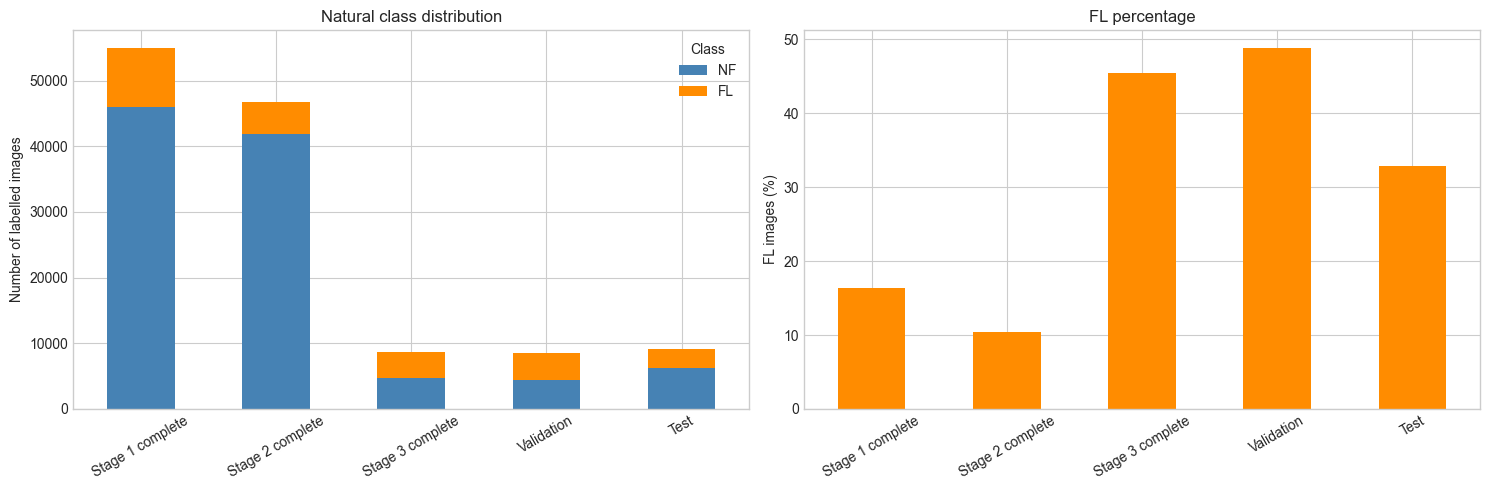

In [24]:
plot_summary = complete_summary.set_index("dataset")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

plot_summary[["NF", "FL"]].plot(
    kind="bar",
    stacked=True,
    color=["steelblue", "darkorange"],
    ax=axes[0],
)

axes[0].set_title("Natural class distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of labelled images")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Class")

plot_summary["FL_percent"].plot(
    kind="bar",
    color="darkorange",
    ax=axes[1],
)

axes[1].set_title("FL percentage")
axes[1].set_xlabel("")
axes[1].set_ylabel("FL images (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [25]:
def find_holdout_candidates(
    stage_data,
    target_fraction=0.15,
    minimum_fl=200,
    minimum_nf=200,
):
    """
    Find possible end-holdouts for one stage.

    Candidates must have:
    - training before holdout;
    - a complete 24-hour NF-only gap;
    - at least minimum_fl FL holdout samples;
    - at least minimum_nf NF holdout samples.
    """
    stage_data = (
        stage_data
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    full_hourly_index = pd.date_range(
        stage_data["timestamp"].min(),
        stage_data["timestamp"].max(),
        freq="h",
    )

    hourly_labels = (
        stage_data
        .set_index("timestamp")["goes_class"]
        .reindex(full_hourly_index)
    )

    # A valid gap ends where the preceding 24 timestamps:
    # 1. are all present, and
    # 2. all have class 0.
    rolling_count = hourly_labels.rolling(24).count()
    rolling_fl = hourly_labels.rolling(24).sum()

    valid_gap_ends = hourly_labels.index[
        (rolling_count == 24)
        & (rolling_fl == 0)
    ]

    stage_fl_percent = (
        100
        * stage_data["goes_class"].mean()
    )

    candidates = []

    for gap_end in valid_gap_ends:
        gap_start = gap_end - pd.Timedelta(hours=23)
        holdout_start = gap_end + pd.Timedelta(hours=1)

        training = stage_data[
            stage_data["timestamp"] < gap_start
        ]

        holdout = stage_data[
            stage_data["timestamp"] >= holdout_start
        ]

        if training.empty or holdout.empty:
            continue

        holdout_fl = int(holdout["goes_class"].sum())
        holdout_nf = len(holdout) - holdout_fl

        if holdout_fl < minimum_fl:
            continue

        if holdout_nf < minimum_nf:
            continue

        retained_samples = len(training) + len(holdout)
        holdout_fraction = len(holdout) / retained_samples
        holdout_fl_percent = 100 * holdout_fl / len(holdout)

        candidates.append({
            "gap_start": gap_start,
            "gap_end": gap_end,
            "train_end": training["timestamp"].max(),
            "holdout_start": holdout["timestamp"].min(),
            "holdout_end": holdout["timestamp"].max(),
            "train_samples": len(training),
            "holdout_samples": len(holdout),
            "holdout_FL": holdout_fl,
            "holdout_NF": holdout_nf,
            "holdout_percent": 100 * holdout_fraction,
            "holdout_FL_percent": holdout_fl_percent,
            "stage_FL_percent": stage_fl_percent,
            "class_shift_points": abs(
                holdout_fl_percent - stage_fl_percent
            ),
            "size_error_points": abs(
                100 * holdout_fraction
                - 100 * target_fraction
            ),
            "holdout_FL_runs": count_fl_runs(holdout),
        })

    candidates = pd.DataFrame(candidates)

    if candidates.empty:
        raise ValueError(
            "No holdout satisfies the requested requirements."
        )

    return (
        candidates
        .sort_values(
            [
                "size_error_points",
                "class_shift_points",
                "gap_start",
            ]
        )
        .reset_index(drop=True)
    )

In [26]:
stage_complete_sets = {
    "Stage 1": stage1_complete,
    "Stage 2": stage2_complete,
    "Stage 3": stage3_complete,
}

candidate_tables = {}

candidate_columns = [
    "gap_start",
    "gap_end",
    "train_samples",
    "holdout_samples",
    "holdout_FL",
    "holdout_NF",
    "holdout_percent",
    "holdout_FL_percent",
    "stage_FL_percent",
    "class_shift_points",
    "size_error_points",
    "holdout_FL_runs",
]

for stage_name, stage_frame in stage_complete_sets.items():
    candidates = find_holdout_candidates(stage_frame)
    candidate_tables[stage_name] = candidates

    print(f"\n{stage_name}: five best candidates")
    display(candidates[candidate_columns].head(5))


Stage 1: five best candidates


,gap_start,gap_end,train_samples,holdout_samples,holdout_FL,holdout_NF,holdout_percent,holdout_FL_percent,stage_FL_percent,class_shift_points,size_error_points,holdout_FL_runs
0,2017-01-06 04:00:00,2017-01-07 03:00:00,46638,8230,330,7900,14.999635,4.009721,16.350288,12.340567,0.000365,16
1,2017-01-06 03:00:00,2017-01-07 02:00:00,46637,8231,330,7901,15.001458,4.009233,16.350288,12.341054,0.001458,16
2,2017-01-06 05:00:00,2017-01-07 04:00:00,46639,8229,330,7899,14.997813,4.010208,16.350288,12.340080,0.002187,16
3,2017-01-06 02:00:00,2017-01-07 01:00:00,46636,8232,330,7902,15.003281,4.008746,16.350288,12.341541,0.003281,16
4,2017-01-06 06:00:00,2017-01-07 05:00:00,46640,8228,330,7898,14.995990,4.010695,16.350288,12.339593,0.004010,16



Stage 2: five best candidates


,gap_start,gap_end,train_samples,holdout_samples,holdout_FL,holdout_NF,holdout_percent,holdout_FL_percent,stage_FL_percent,class_shift_points,size_error_points,holdout_FL_runs
0,2022-09-06 00:00:00,2022-09-06 23:00:00,39760,7016,2870,4146,14.999145,40.906499,10.395299,30.511200,0.000855,74
1,2022-09-05 23:00:00,2022-09-06 22:00:00,39759,7017,2870,4147,15.001283,40.900670,10.395299,30.505371,0.001283,74
2,2022-09-06 01:00:00,2022-09-07 00:00:00,39761,7015,2870,4145,14.997007,40.912331,10.395299,30.517032,0.002993,74
3,2022-09-05 22:00:00,2022-09-06 21:00:00,39758,7018,2870,4148,15.003421,40.894842,10.395299,30.499543,0.003421,74
4,2022-09-06 02:00:00,2022-09-07 01:00:00,39762,7014,2870,4144,14.994869,40.918164,10.395299,30.522865,0.005131,74



Stage 3: five best candidates


,gap_start,gap_end,train_samples,holdout_samples,holdout_FL,holdout_NF,holdout_percent,holdout_FL_percent,stage_FL_percent,class_shift_points,size_error_points,holdout_FL_runs
0,2024-05-06 06:00:00,2024-05-07 05:00:00,7352,1273,814,459,14.759420,63.943441,45.427217,18.516224,0.240580,16
1,2024-05-06 07:00:00,2024-05-07 06:00:00,7353,1272,814,458,14.747826,63.993711,45.427217,18.566494,0.252174,16
2,2024-05-06 08:00:00,2024-05-07 07:00:00,7354,1271,814,457,14.736232,64.044060,45.427217,18.616843,0.263768,16
3,2024-05-06 09:00:00,2024-05-07 08:00:00,7355,1270,814,456,14.724638,64.094488,45.427217,18.667271,0.275362,16
4,2024-05-06 10:00:00,2024-05-07 09:00:00,7356,1269,814,455,14.713043,64.144996,45.427217,18.717779,0.286957,16


In [27]:
selected_splits = {}

for stage_name, stage_frame in stage_complete_sets.items():
    selected = candidate_tables[stage_name].iloc[0]

    gap_start = selected["gap_start"]
    gap_end = selected["gap_end"]
    holdout_start = selected["holdout_start"]

    training = stage_frame[
        stage_frame["timestamp"] < gap_start
    ].copy()

    internal_gap = stage_frame[
        stage_frame["timestamp"].between(
            gap_start,
            gap_end,
        )
    ].copy()

    holdout = stage_frame[
        stage_frame["timestamp"] >= holdout_start
    ].copy()

    selected_splits[stage_name] = {
        "training": training,
        "gap": internal_gap,
        "holdout": holdout,
        "gap_start": gap_start,
        "gap_end": gap_end,
    }

print("Highest-ranked holdout candidate selected for each stage.")

Highest-ranked holdout candidate selected for each stage.


In [28]:
split_rows = []

for stage_name, split in selected_splits.items():
    training = split["training"]
    gap = split["gap"]
    holdout = split["holdout"]

    train_row = summarize_period(
        f"{stage_name} train",
        training,
    )
    train_row["role"] = "Train"

    gap_row = summarize_period(
        f"{stage_name} internal gap",
        gap,
        planned_start=split["gap_start"],
        planned_end=split["gap_end"],
    )
    gap_row["role"] = "NF gap"

    holdout_row = summarize_period(
        f"{stage_name} holdout",
        holdout,
    )
    holdout_row["role"] = "Holdout"

    retained = len(training) + len(holdout)

    train_row["holdout_percent"] = np.nan
    gap_row["holdout_percent"] = np.nan
    holdout_row["holdout_percent"] = (
        100 * len(holdout) / retained
    )

    split_rows.extend([
        train_row,
        gap_row,
        holdout_row,
    ])

split_summary = pd.DataFrame(split_rows)

display_columns = [
    "dataset",
    "role",
    "actual_start",
    "actual_end",
    "samples",
    "FL",
    "NF",
    "FL_percent",
    "FL_runs",
    "MX_events",
    "holdout_percent",
]

display(split_summary[display_columns])

,dataset,role,actual_start,actual_end,samples,FL,NF,FL_percent,FL_runs,MX_events,holdout_percent
0,Stage 1 train,Train,2010-12-06 07:00:00,2017-01-06 03:00:00,46638,8645,37993,18.536387,382,739,NaN
1,Stage 1 internal gap,NF gap,2017-01-06 04:00:00,2017-01-07 03:00:00,24,0,24,0.000000,0,0,NaN
2,Stage 1 holdout,Holdout,2017-01-07 04:00:00,2017-12-31 23:00:00,8230,330,7900,4.009721,16,43,14.999635
3,Stage 2 train,Train,2018-01-02 00:00:00,2022-09-05 23:00:00,39760,1995,37765,5.017606,76,160,NaN
4,Stage 2 internal gap,NF gap,2022-09-06 00:00:00,2022-09-06 23:00:00,24,0,24,0.000000,0,0,NaN
5,Stage 2 holdout,Holdout,2022-09-07 00:00:00,2023-06-29 22:00:00,7016,2870,4146,40.906499,74,271,14.999145
6,Stage 3 train,Train,2023-06-30 23:00:00,2024-05-06 05:00:00,7352,3115,4237,42.369423,97,286,NaN
7,Stage 3 internal gap,NF gap,2024-05-06 06:00:00,2024-05-07 05:00:00,24,0,24,0.000000,0,0,NaN
8,Stage 3 holdout,Holdout,2024-05-07 06:00:00,2024-06-29 10:00:00,1273,814,459,63.943441,16,118,14.759420


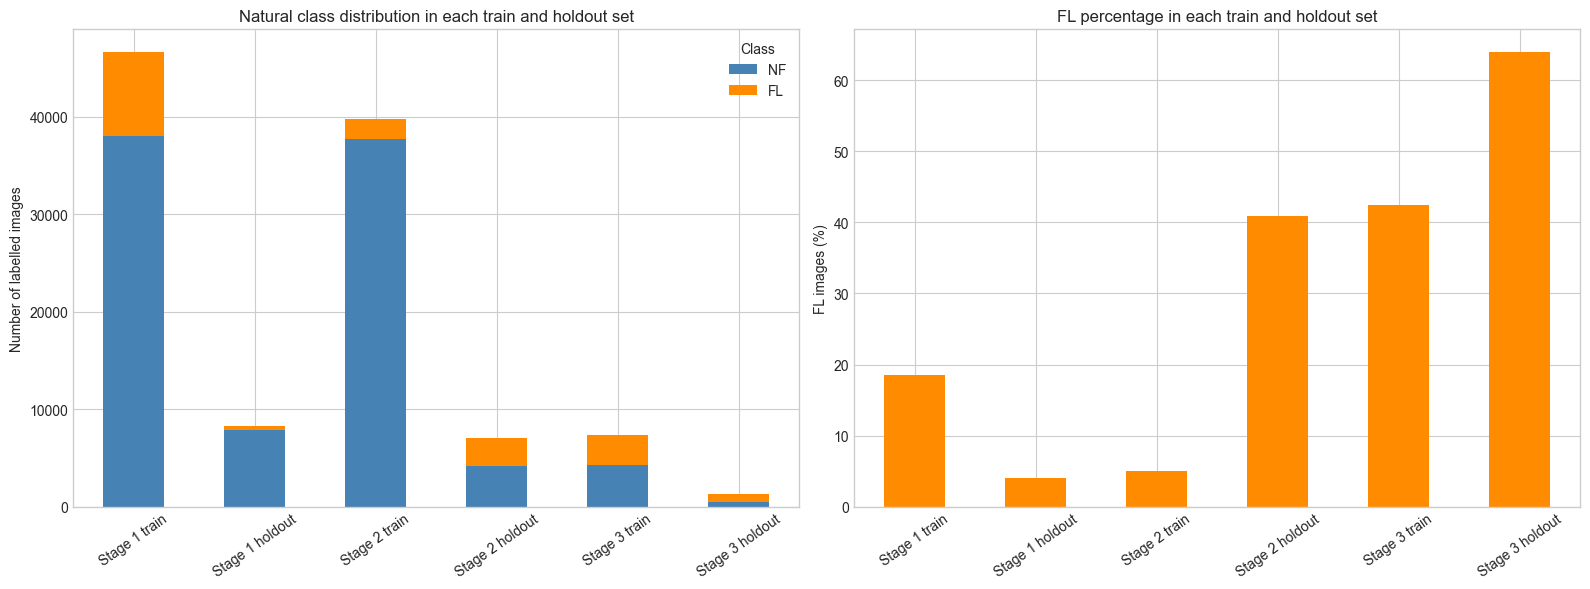

In [29]:
train_holdout_summary = split_summary[
    split_summary["role"].isin(["Train", "Holdout"])
].copy()

plot_frame = (
    train_holdout_summary
    .set_index("dataset")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

plot_frame[["NF", "FL"]].plot(
    kind="bar",
    stacked=True,
    color=["steelblue", "darkorange"],
    ax=axes[0],
)

axes[0].set_title(
    "Natural class distribution in each train and holdout set"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of labelled images")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="Class")

plot_frame["FL_percent"].plot(
    kind="bar",
    color="darkorange",
    ax=axes[1],
)

axes[1].set_title("FL percentage in each train and holdout set")
axes[1].set_xlabel("")
axes[1].set_ylabel("FL images (%)")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In [30]:
future_summary = pd.DataFrame([
    summarize_period(
        "Validation",
        validation_data,
        planned_start=BLOCK_LIMITS["Validation"][0],
        planned_end=BLOCK_LIMITS["Validation"][1],
    ),
    summarize_period(
        "Test",
        test_data,
        planned_start=BLOCK_LIMITS["Test"][0],
        planned_end=BLOCK_LIMITS["Test"][1],
    ),
])

display(future_summary[[
    "dataset",
    "planned_start",
    "planned_end",
    "samples",
    "missing_hours",
    "coverage_percent",
    "FL",
    "NF",
    "FL_percent",
    "FL_runs",
    "MX_events",
]])

,dataset,planned_start,planned_end,samples,missing_hours,coverage_percent,FL,NF,FL_percent,FL_runs,MX_events
0,Validation,2024-06-30 11:00:00,2025-06-30 23:00:00,8493,280,96.808389,4142,4351,48.769575,99,522
1,Test,2025-07-02 00:00:00,2026-07-31 23:00:00,9187,293,96.909283,3018,6169,32.850767,90,345


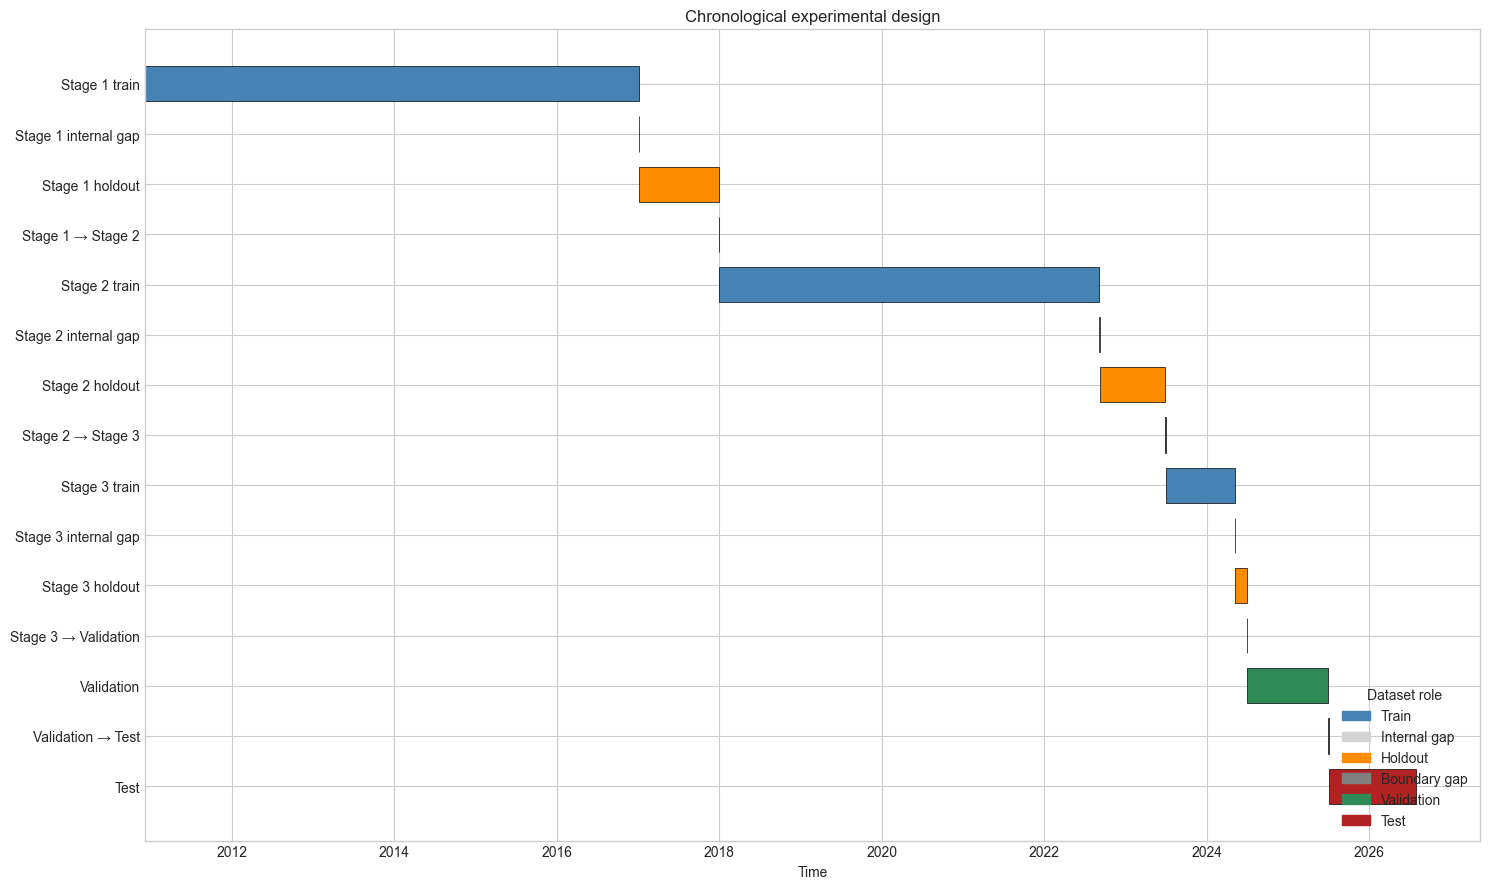

In [31]:
timeline_segments = []

colors = {
    "Train": "steelblue",
    "Internal gap": "lightgray",
    "Holdout": "darkorange",
    "Boundary gap": "gray",
    "Validation": "seagreen",
    "Test": "firebrick",
}

for stage_name, split in selected_splits.items():
    timeline_segments.extend([
        {
            "name": f"{stage_name} train",
            "start": split["training"]["timestamp"].min(),
            "end": split["training"]["timestamp"].max(),
            "type": "Train",
        },
        {
            "name": f"{stage_name} internal gap",
            "start": split["gap_start"],
            "end": split["gap_end"],
            "type": "Internal gap",
        },
        {
            "name": f"{stage_name} holdout",
            "start": split["holdout"]["timestamp"].min(),
            "end": split["holdout"]["timestamp"].max(),
            "type": "Holdout",
        },
    ])

for gap_name, (start, end) in MAJOR_GAPS.items():
    timeline_segments.append({
        "name": gap_name,
        "start": start,
        "end": end,
        "type": "Boundary gap",
    })

timeline_segments.extend([
    {
        "name": "Validation",
        "start": BLOCK_LIMITS["Validation"][0],
        "end": BLOCK_LIMITS["Validation"][1],
        "type": "Validation",
    },
    {
        "name": "Test",
        "start": BLOCK_LIMITS["Test"][0],
        "end": BLOCK_LIMITS["Test"][1],
        "type": "Test",
    },
])

timeline = (
    pd.DataFrame(timeline_segments)
    .sort_values("start")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(15, 9))

for index, row in timeline.iterrows():
    duration_days = (
        row["end"] - row["start"]
    ) / pd.Timedelta(days=1)

    ax.barh(
        index,
        duration_days,
        left=row["start"],
        height=0.7,
        color=colors[row["type"]],
        edgecolor="black",
        linewidth=0.5,
    )

ax.set_yticks(range(len(timeline)))
ax.set_yticklabels(timeline["name"])
ax.invert_yaxis()
ax.set_title("Chronological experimental design")
ax.set_xlabel("Time")

legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=color,
        label=label,
    )
    for label, color in colors.items()
]

ax.legend(
    handles=legend_handles,
    title="Dataset role",
    loc="lower right",
)

plt.tight_layout()
plt.show()

In [32]:
# Check each stage internally.
for stage_name, split in selected_splits.items():
    training = split["training"]
    gap = split["gap"]
    holdout = split["holdout"]

    assert len(gap) == 24
    assert int(gap["goes_class"].sum()) == 0

    assert training["timestamp"].max() < gap["timestamp"].min()
    assert gap["timestamp"].max() < holdout["timestamp"].min()

    assert set(training["label"]).isdisjoint(
        set(holdout["label"])
    )

    holdout_fl = int(holdout["goes_class"].sum())
    holdout_nf = len(holdout) - holdout_fl

    assert holdout_fl >= 200
    assert holdout_nf >= 200

# Check the ordering of the major datasets.
assert (
    stage1_complete["timestamp"].max()
    < stage2_complete["timestamp"].min()
)

assert (
    stage2_complete["timestamp"].max()
    < stage3_complete["timestamp"].min()
)

assert (
    stage3_complete["timestamp"].max()
    < validation_data["timestamp"].min()
)

assert (
    validation_data["timestamp"].max()
    < test_data["timestamp"].min()
)

# Verify that all available observations are assigned exactly once.
assigned_frames = []

for split in selected_splits.values():
    assigned_frames.extend([
        split["training"],
        split["gap"],
        split["holdout"],
    ])

for gap_start, gap_end in MAJOR_GAPS.values():
    assigned_frames.append(
        data[
            data["timestamp"].between(
                gap_start,
                gap_end,
            )
        ]
    )

assigned_frames.extend([
    validation_data,
    test_data,
])

assigned_labels = pd.concat(
    [frame["label"] for frame in assigned_frames],
    ignore_index=True,
)

assert assigned_labels.is_unique
assert len(assigned_labels) == len(data)
assert set(assigned_labels) == set(data["label"])

print("All checks passed:")
print("- No observation overlap")
print("- Correct chronological ordering")
print("- All internal gaps are complete 24-hour NF-only gaps")
print("- All major gaps are complete 24-hour NF-only gaps")
print("- Validation occurs after Stage 3")
print("- Test occurs after validation")
print("- Every available observation is assigned exactly once")
print("- No CSV files were created")

All checks passed:
- No observation overlap
- Correct chronological ordering
- All internal gaps are complete 24-hour NF-only gaps
- All major gaps are complete 24-hour NF-only gaps
- Validation occurs after Stage 3
- Test occurs after validation
- Every available observation is assigned exactly once
- No CSV files were created


In [33]:
final_design_rows = []

for stage_name, split in selected_splits.items():
    training = split["training"]
    holdout = split["holdout"]

    final_design_rows.append({
        "dataset": f"{stage_name} train",
        "start": training["timestamp"].min(),
        "end": training["timestamp"].max(),
        "samples": len(training),
        "FL": int(training["goes_class"].sum()),
        "NF": int((training["goes_class"] == 0).sum()),
    })

    final_design_rows.append({
        "dataset": f"{stage_name} holdout",
        "start": holdout["timestamp"].min(),
        "end": holdout["timestamp"].max(),
        "samples": len(holdout),
        "FL": int(holdout["goes_class"].sum()),
        "NF": int((holdout["goes_class"] == 0).sum()),
    })

for name, frame in [
    ("Validation", validation_data),
    ("Test", test_data),
]:
    final_design_rows.append({
        "dataset": name,
        "start": frame["timestamp"].min(),
        "end": frame["timestamp"].max(),
        "samples": len(frame),
        "FL": int(frame["goes_class"].sum()),
        "NF": int((frame["goes_class"] == 0).sum()),
    })

final_design = pd.DataFrame(final_design_rows)

final_design["FL_percent"] = (
    100 * final_design["FL"] / final_design["samples"]
)

display(final_design)

,dataset,start,end,samples,FL,NF,FL_percent
0,Stage 1 train,2010-12-06 07:00:00,2017-01-06 03:00:00,46638,8645,37993,18.536387
1,Stage 1 holdout,2017-01-07 04:00:00,2017-12-31 23:00:00,8230,330,7900,4.009721
2,Stage 2 train,2018-01-02 00:00:00,2022-09-05 23:00:00,39760,1995,37765,5.017606
3,Stage 2 holdout,2022-09-07 00:00:00,2023-06-29 22:00:00,7016,2870,4146,40.906499
4,Stage 3 train,2023-06-30 23:00:00,2024-05-06 05:00:00,7352,3115,4237,42.369423
5,Stage 3 holdout,2024-05-07 06:00:00,2024-06-29 10:00:00,1273,814,459,63.943441
6,Validation,2024-06-30 11:00:00,2025-06-30 23:00:00,8493,4142,4351,48.769575
7,Test,2025-07-02 00:00:00,2026-07-31 23:00:00,9187,3018,6169,32.850767


## Interpretation

This EDA evaluates the proposed split without creating any final files.

Important points:

1. The repaired December 31, 2018 observations are included in Stage 2.
2. The unavailable January 2, 2019 observations remain documented as missing.
3. Holdouts are selected chronologically from the end of each stage.
4. Each training–holdout boundary contains a complete 24-hour NF-only gap.
5. Every major dataset boundary contains a complete 24-hour NF-only gap.
6. Stage 1 and Stage 2 holdouts are close to 15%.
7. Stage 3 uses the closest valid holdout with enough FL and NF observations.
8. Validation and test remain untouched by training and holdout selection.
9. The test set must not be used for hyperparameter or threshold selection.
10. Final stage CSV files should be created only after reviewing and accepting these EDA results.